In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [12]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [14]:
books = []

for book in soup.select("article.product_pod"):

    title = book.h3.a["title"]

    price = book.select_one(".price_color").text.strip()

    rating = book.select_one(".star-rating")["class"][1]

    availability = book.select_one(".availability").text.strip()

    books.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability
    })

print("Total books:", len(books))

Total books: 20


In [15]:
df = pd.DataFrame(books)

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [16]:
print(df.shape)
print(df.info())
print(df.head())

(20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         20 non-null     object
 1   Price         20 non-null     object
 2   Rating        20 non-null     object
 3   Availability  20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes
None
                                   Title    Price Rating Availability
0                   A Light in the Attic  Â£51.77  Three     In stock
1                     Tipping the Velvet  Â£53.74    One     In stock
2                             Soumission  Â£50.10    One     In stock
3                          Sharp Objects  Â£47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  Â£54.23   Five     In stock


In [17]:
df.isnull().sum()

,0
Title,0
Price,0
Rating,0
Availability,0


In [22]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)


In [28]:
average_rating = df["Rating"].mean()

print("Average Rating:", round(average_rating, 2))

rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Average Rating: nan
Series([], Name: count, dtype: int64)


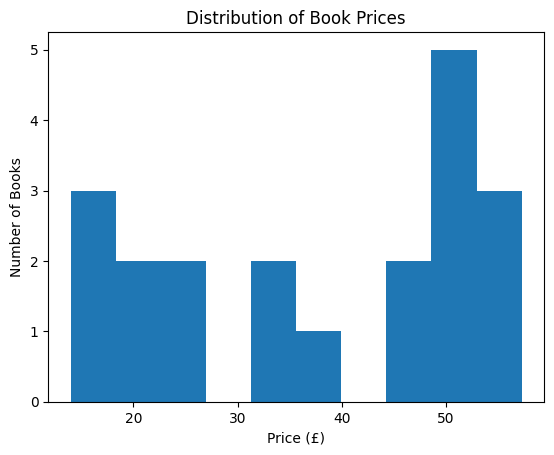

In [31]:
plt.hist(df["Price"], bins=10)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [32]:
top_10_cheapest = df.sort_values(
    by="Price",
    ascending=True
).head(10)

top_10_cheapest[["Title", "Price", "Rating"]]

,Title,Price,Rating
10,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,NaN
12,Set Me Free,17.46,NaN
7,The Coming Woman: A Novel Based on the Life of...,17.93,NaN
11,Shakespeare's Sonnets,20.66,NaN
8,The Boys in the Boat: Nine Americans and Their...,22.60,NaN
5,The Requiem Red,22.65,NaN
16,Olio,23.88,NaN
6,The Dirty Little Secrets of Getting Your Dream...,33.34,NaN
14,Rip it Up and Start Again,35.02,NaN
17,Mesaerion: The Best Science Fiction Stories 18...,37.59,NaN


In [33]:
top_10_expensive = df.sort_values(
    by="Price",
    ascending=False
).head(10)

top_10_expensive[["Title", "Price", "Rating"]]

,Title,Price,Rating
15,Our Band Could Be Your Life: Scenes from the A...,57.25,NaN
4,Sapiens: A Brief History of Humankind,54.23,NaN
1,Tipping the Velvet,53.74,NaN
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,NaN
9,The Black Maria,52.15,NaN
0,A Light in the Attic,51.77,NaN
18,Libertarianism for Beginners,51.33,NaN
2,Soumission,50.10,NaN
3,Sharp Objects,47.82,NaN
19,It's Only the Himalayas,45.17,NaN


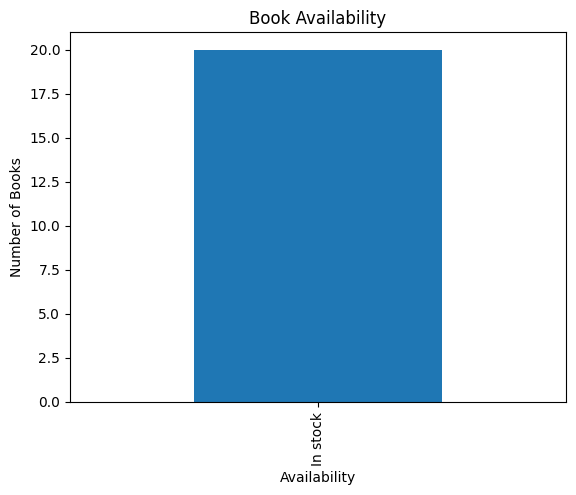

In [34]:
df["Availability"].value_counts()
df["Availability"].value_counts().plot(kind="bar")

plt.title("Book Availability")
plt.xlabel("Availability")
plt.ylabel("Number of Books")

plt.show()

In [36]:
df.to_csv("books_data.csv", index=False)

print("CSV file created successfully!")

df.to_excel("books_data.xlsx", index=False)
print("Excel file created successfully!")

CSV file created successfully!
Excel file created successfully!
